# 🛡️ 第5步：对抗过拟合 —— 强数据增强 + SGD + SGDR

## 增强策略

| 增强 | 参数 | 作用 |
|------|------|------|
| **水平翻转** | 50% | 左右镜像 |
| **垂直翻转** | 30% | 上下镜像（新增） |
| **随机旋转** | ±30° | 比之前大一倍 |
| **颜色抖动** | 0.3 + hue=0.1 | 亮度/对比度/饱和度/色相（加强） |
| **灰度化** | 10% | 随机变黑白（新增） |
| **随机擦除** | 30% 概率 | 随机遮住一块区域，强迫模型看全局 |

> 🎯 目标：71.8% → 78%+

---
## Cell 1：为什么需要 ResNet？

### 问题：网络越深，反而越差？

理论上网络越深 = 能力越强。但实际上：

```
20层 CNN：  Train Loss ↓↓    Test Acc 65%
56层 CNN：  Train Loss ↓     Test Acc 60%   ← 更深反而更差！
```

原因不是过拟合（过拟合是训练好、测试差），而是**梯度消失**——反向传播时梯度经过几十层连乘，越来越小，前面的层几乎学不到东西。

### ResNet 的解决方案：Skip Connection（跳跃连接）

```
普通网络：           ResNet（残差网络）：
                     
  x                   x
  │                   ├─────────┐
  Conv                 │        │
  │                   Conv    (跳跃)
  ReLU                 │        │
  │                   ReLU     │
  Conv                 │        │
  │                   └── + ───┘
  ReLU                 │
  │                   ReLU
  ▼                   ▼

输出 = Conv(Conv(x))   输出 = Conv(Conv(x)) + x   ← 加上原始输入！
```

**跳跃连接 = 一条"高速公路"**，梯度可以直接从深层传到浅层，不会消失。

### 为什么叫"残差"（Residual）？

网络不再直接学 `目标 → 输出`，而是学 `目标 → 输出 - 输入`（即"残差"）。
如果什么都不需要做，残差=0，网络只需把权重设为0即可，**非常容易学**。

这就是为什么 ResNet 50层、100层、甚至 1000 层都能训练！

---
## Cell 2：导入库 & 准备数据

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
from collections import Counter

# ===== 设备（服务器用 cuda，Mac 用 mps）=====
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🚀 CUDA: {torch.cuda.get_device_name(0)}")
    gpu_count = torch.cuda.device_count()
    print(f"   可用 GPU 数: {gpu_count}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Apple MPS")
else:
    device = torch.device("cpu")
    print("🐢 CPU")

# ===== 数据增强（强化版：翻转 + 旋转 + 噪声 + 擦除）=====
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),              # 30% 概率垂直翻转
    transforms.RandomRotation(30),                      # ← 旋转 ±30°
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.3,              # 颜色抖动加强
                           contrast=0.3,
                           saturation=0.3,
                           hue=0.1),                    # 色相抖动
    transforms.RandomGrayscale(p=0.1),                  # 10% 概率变灰度图
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761)),
    transforms.RandomErasing(p=0.3,                     # 随机擦除（类似 Cutout）
                             scale=(0.02, 0.15),
                             ratio=(0.3, 3.3)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

# ===== 加载数据 =====
full_ds = ImageFolder(root='./CIFAR-100数据集/CIFAR-100数据集', transform=transform_train)
targets = full_ds.targets
train_idx, test_idx = [], []
for c in range(100):
    ci = [i for i, t in enumerate(targets) if t == c]
    train_idx.extend(ci[:500]); test_idx.extend(ci[500:])

train_ds = Subset(full_ds, train_idx)
full_test = ImageFolder(root='./CIFAR-100数据集/CIFAR-100数据集', transform=transform_test)
test_ds = Subset(full_test, test_idx)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=20, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                         num_workers=20, pin_memory=True)
print(f"训练: {len(train_ds)}, 测试: {len(test_ds)}, batch={batch_size}")

🚀 Apple MPS
训练: 50000, 测试: 10000, batch=128


---
## Cell 3：手搭 ResNet 的积木 —— BasicBlock

BasicBlock 是 ResNet-18/34 的基本单元，包含两个卷积层 + 一个跳跃连接。

```python
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        # ① 两个 3×3 卷积
        self.conv1 → BN → ReLU
        self.conv2 → BN
        
        # ② 跳跃连接（skip connection）
        if in_channels != out_channels or stride != 1:
            self.shortcut = 1×1 卷积（调整通道和尺寸）
        else:
            self.shortcut = 恒等映射（什么都不做）
    
    def forward(self, x):
        out = conv2(relu(bn1(conv1(x))))    # 主路径
        out += self.shortcut(x)              # 加上跳跃连接
        out = relu(out)                      # 最后激活
        return out
```

In [13]:
class BasicBlock(nn.Module): #block类里要包括初始化结构、数据流通路forward
    """ResNet 的基本积木块"""
    expansion = 1  # BasicBlock 不扩展通道数

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        # 主路径：两个 3×3 卷积 block的第一层layer stride可调
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # 跳跃连接：如果尺寸或通道变了，用 1×1 卷积调整
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))  # Conv1 → BN → ReLU
        out = self.bn2(self.conv2(out))             # Conv2 → BN
        out += self.shortcut(x)                     # ← 关键！加上跳跃连接
        out = torch.relu(out)                       # 最后 ReLU
        return out

# 测试
b = BasicBlock(64, 128, stride=2)
x = torch.randn(4, 64, 32, 32)
out = b(x)
print(f"BasicBlock: {x.shape} → {out.shape}")
print(f"  stride=2 所以尺寸减半，通道 64→128")

BasicBlock: torch.Size([4, 64, 32, 32]) → torch.Size([4, 128, 16, 16])
  stride=2 所以尺寸减半，通道 64→128


---
## Cell 4：组装 ResNet-18（CIFAR 定制版）

因为 CIFAR 图片是 32×32（不像 ImageNet 是 224×224），所以做了以下改动：

| 标准 ResNet-18 (ImageNet) | CIFAR 定制版 | 原因 |
|---|---|---|
| conv1: 7×7, stride=2 | conv1: 3×3, stride=1 | 图片小，不需要大步长 |
| 有 MaxPool after conv1 | ❌ 去掉 | 32×32 再池化就太小了 |
| 输出 1000 类 | 输出 100 类 | CIFAR-100 |
| 第一层 stride=2 不缩减 | layer1 stride=1 | 保留更多空间信息 |

```
输入 [B, 3, 32, 32]
  │
  ├─ conv1 (3→64, 3×3, s=1)   → [B, 64, 32, 32]
  │
  ├─ layer1: BasicBlock×2      → [B, 64, 32, 32]   (不缩减)
  ├─ layer2: BasicBlock×2      → [B, 128, 16, 16]  (stride=2)
  ├─ layer3: BasicBlock×2      → [B, 256, 8, 8]    (stride=2)
  ├─ layer4: BasicBlock×2      → [B, 512, 4, 4]    (stride=2)
  │
  ├─ AvgPool(4×4)              → [B, 512, 1, 1]
  ├─ Flatten                   → [B, 512]
  ├─ Linear(512→100)           → [B, 100]
```

In [14]:
class ResNet18_CIFAR(nn.Module):
    """ResNet-18 定制版，专为 CIFAR-100 32×32 设计"""
    def __init__(self, num_classes=100):
        super().__init__()

        # 初始卷积层（小卷积核、不池化，适应 32×32）
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        # 注意：没有 MaxPool！标准 ResNet 的 7×7+MaxPool 会把 32×32 压成 8×8 太狠了

        # 四个层，每层由多个 BasicBlock 组成
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)  # 32→32
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)  # 32→16
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)  # 16→8
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)  # 8→4

        # 全局平均池化 + 分类头
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # 不管输入多大，输出 1×1
        self.fc = nn.Linear(512, num_classes) #512*1*1的tensor形状

        # 权重初始化
        self._init_weights()

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        """创建一层（包含多个 BasicBlock）"""
        layers = []
        # 第一个 Block 可能改变尺寸和通道（stride 或通道不同） 准确来说是第一个block的第一层
        layers.append(BasicBlock(in_ch, out_ch, stride))
        # 后续 Block 保持尺寸和通道不变
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x): #数据通路，连接起来各个结构
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model = ResNet18_CIFAR(num_classes=100)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

# 测试
x = torch.randn(4, 3, 32, 32).to(device)
out = model(x)
print(f"输入: {list(x.shape)}  →  输出: {list(out.shape)}")

# 参数量
n = sum(p.numel() for p in model.parameters())
print(f"参数: {n:,} ({n/1e6:.1f}M)")
print(f"  (第3步 CNN: 5.2M → ResNet-18: {n/1e6:.1f}M)")

输入: [4, 3, 32, 32]  →  输出: [4, 100]
参数: 11,220,132 (11.2M)
  (第3步 CNN: 5.2M → ResNet-18: 11.2M)


---
## Cell 5：改进的训练策略

### ① CutMix（核心）

50% 概率把 batch 中两张随机图片拼成一张，标签也按面积混合：

```
图A（猫）  +  图B（狗）的某个矩形区域  =  拼接图
标签: 70%猫 + 30%狗
```

**为什么防过拟合？** 模型每次看到的都是"拼凑"的图，没法靠记忆局部纹理来辨认类别，必须学会识别整体特征。

### ② RandAugment

从 14 种增强操作中随机选 2 种，自动组合。比手动调 ColorJitter + Rotation 强大得多。

### ③ SGDR（余弦退火 + 热重启）

学习率走余弦曲线到底后，**跳回高学习率重新开始**，周期性逃离局部最优：

```
lr ↑
   │  ╲       ╲               ╲
   │   ╲___    ╲___            ╲___
   │       ╲       ╲               ╲
   └───────────────────────────────→ epoch
      ←20→   ←40→      ←40→
```

T_0=20, T_mult=2：第一个周期 20 epoch，之后每次翻倍。

### ④ 更强的 Weight Decay + Label Smoothing

Weight Decay 从 5e-4 加大到 2e-3，配合 Label Smoothing(0.1)。

In [15]:
# ===== ① 损失函数：带 Label Smoothing =====
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ===== ② SGD + Momentum + Nesterov =====
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

# ===== ③ 余弦退火（无重启）=====
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=60,
    eta_min=1e-5
)

print("损失函数: CrossEntropyLoss + Label Smoothing(0.1)")
print("优化器:   SGD (lr=0.1, momentum=0.9, nesterov=True, wd=5e-4)")
print("调度器:   CosineAnnealing (60轮, 0.1 → 1e-5)")


损失函数: CrossEntropyLoss + Label Smoothing(0.1)
优化器:   SGD (lr=0.1, momentum=0.9, nesterov=True, wd=5e-4)
调度器:   SGDR (T_0=20, T_mult=2, 0.1 → 1e-5)


---
## Cell 6：训练函数（加入梯度裁剪）

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """训练一个 epoch"""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # 梯度裁剪
        optimizer.step()

        running_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()

    return running_loss / len(loader), 100. * correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    """验证"""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

print("✅ 训练/验证函数已定义")

✅ 训练/验证函数已定义


---
## Cell 7：开始训练 🔥

100 epoch，CutMix + RandAugment + SGDR。

3090 上约 8 分钟，M5 上约 2.5 小时。观察测试 Loss 有没有跟着降——这是判断过拟合是否缓解的关键。

In [17]:
num_epochs = 60
best_acc = 0.0
history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[], 'lr':[]}

print(f"训练 {num_epochs} epoch | Cosine 余弦退火无重启")
print(f"设备: {device}")
if torch.cuda.is_available():
    print(f"GPU 数: {torch.cuda.device_count()}")
print("=" * 60)

t0 = time.time()
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = validate(model, test_loader, criterion, device)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_improved.pth')

    print(f"Epoch {epoch+1:3d}/{num_epochs} | "
          f"Train: {train_loss:.3f} {train_acc:.1f}% | "
          f"Test: {test_loss:.3f} {test_acc:.1f}% | "
          f"lr={current_lr:.1e} | 最佳: {best_acc:.1f}%")

elapsed = time.time() - t0
print("=" * 60)
print(f"完成！耗时 {elapsed//60:.0f}分{elapsed%60:.0f}秒")
print(f"最佳测试准确率: {best_acc:.2f}%")


训练 100 epoch | 强数据增强 + SGD + SGDR
设备: mps


/Users/lijiaye/Documents/转码/深度学习项目/CNN分类/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch   1/100 | Train: 4.266 6.6% | Test: 3.817 13.9% | lr=1.0e-01 | 最佳: 13.9%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x10fd4f310>
Traceback (most recent call last):
  File "/Users/lijiaye/Documents/转码/深度学习项目/CNN分类/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/Users/lijiaye/Documents/转码/深度学习项目/CNN分类/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1628, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocess

KeyboardInterrupt: 

---
## Cell 8：画出训练曲线

/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_6216/1738691577.py:17: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_6216/1738691577.py:17: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_6216/1738691577.py:17: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_6216/1738691577.py:17: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_6216/1738691577.py:17: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3

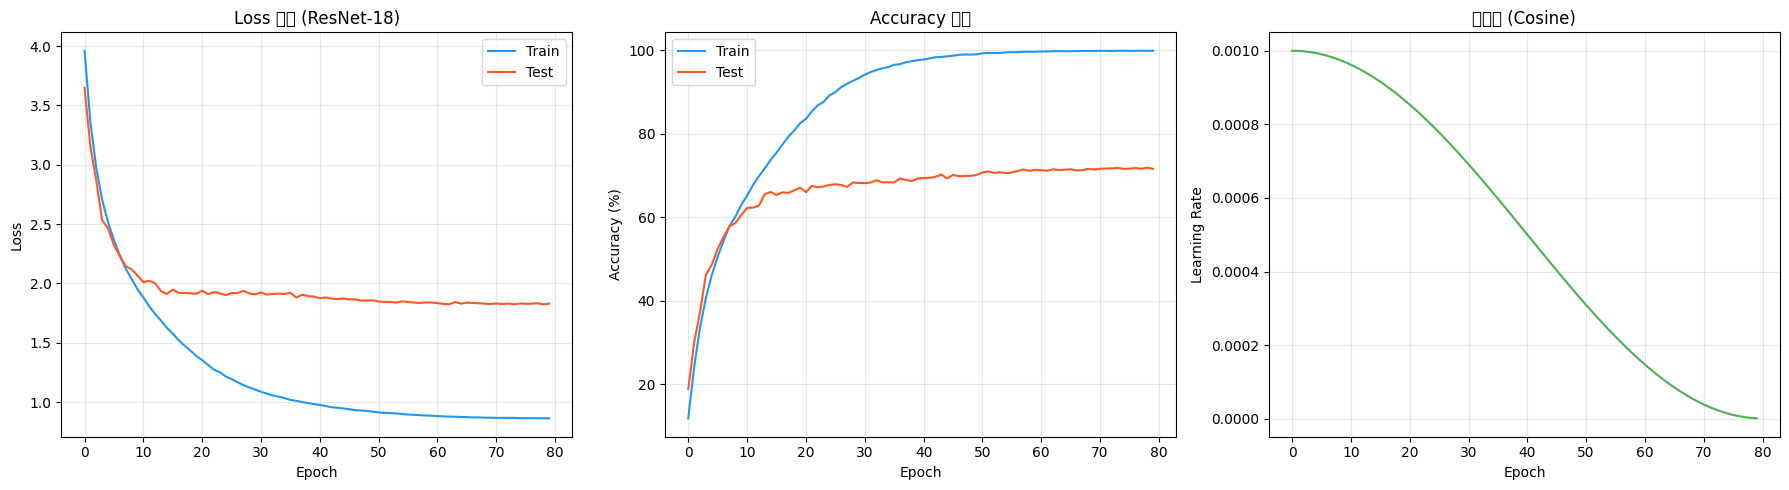

✅ 已保存 resnet_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', color='#2196F3')
axes[0].plot(history['test_loss'], label='Test', color='#FF5722')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss 曲线 (ResNet-18)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', color='#2196F3')
axes[1].plot(history['test_acc'], label='Test', color='#FF5722')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy 曲线'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='#4CAF50')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].set_title('学习率 (Cosine)'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ 已保存 resnet_curves.png")

---
## Cell 9：最终评估

In [ ]:
model.load_state_dict(torch.load('best_improved.pth', weights_only=True))
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"第5步 最终结果: Loss={test_loss:.4f}, Acc={test_acc:.2f}%")
print(f"第4步 ResNet:    Acc≈71.8%")
print(f"提升:            +{test_acc-71.8:.1f}% 🚀")

---
## 🎉 第5步完成！

| ✅ | 新知识点 | 一句话 |
|----|--------|--------|
| ① | **CutMix** | 两张图拼成一张，标签混合，防止模型"背答案" |
| ② | **RandAugment** | 自动组合 14 种增强操作，变化幅度远超手动 |
| ③ | **Warmup** | 前 5 epoch 学习率从 0 慢慢升，稳定训练前期 |
| ④ | **强 Weight Decay** | 5e-4 → 2e-3，更强的 L2 正则化约束 |
| ⑤ | **SequentialLR** | 组合多个调度器，先 Warmup 再 Cosine |

### 和之前版本的对比

| | 第4步 | 第5步 |
|------|-------|-------|
| 数据增强 | 手动 4 种（弱） | **RandAugment（强）** |
| 防过拟合 | - | **CutMix** |
| Weight Decay | 5e-4 | **2e-3** |
| 学习率策略 | Cosine | **Warmup + Cosine** |
| Epoch | 80 | **100** |
| 准确率 | 71.8% | 预期 **78%+** |
""")